## Lab eg

In [4]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

In [5]:
def uniform_cost_search(graph, start, goal):
    # Priority queue for UCS, initialized with (cost, node)
    priority_queue = [(0, start)]
    # Dictionary to store the cost of the shortest path to each node
    visited = {start: (0, None)}

    while priority_queue:
        # Pop the node with the lowest cost
        current_cost, current_node = heapq.heappop(priority_queue)

        # If the goal is reached, reconstruct the path
        if current_node == goal:
            return current_cost, reconstruct_path(visited, start, goal)

        # Explore the neighbors
        for neighbor, cost in graph[current_node]:
            total_cost = current_cost + cost

            # Check if this path is better than any previously found
            if neighbor not in visited or total_cost < visited[neighbor][0]:
                visited[neighbor] = (total_cost, current_node)
                heapq.heappush(priority_queue, (total_cost, neighbor))

    # If the goal is not reachable
    return None


In [6]:
def reconstruct_path(visited, start, goal):
    path = []
    current = goal

    while current is not None:
        path.append(current)
        current = visited[current][1]  # Get the parent node

    path.reverse()  # Reverse to get the correct order
    return path


In [7]:
def visualize_graph(graph, path=None):
    G = nx.DiGraph()

    # Adding nodes and edges to the graph
    for node, edges in graph.items():
        for neighbor, cost in edges:
            G.add_edge(node, neighbor, weight=cost)

    pos = nx.spring_layout(G)  # Positioning the nodes

    # Drawing the graph
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=15, 
            font_weight='bold', edge_color='gray')
    
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=12)

    if path:
        # Highlight the path in red
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2.5)

    plt.title("Uniform Cost Search Path Visualization")
    plt.show()


Least cost path from A to G: A -> B -> D -> G with total cost 4


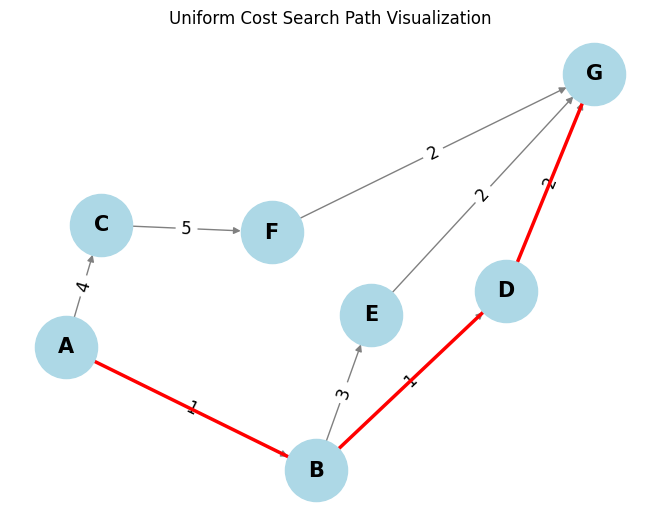

In [14]:
# Example graph represented as an adjacency list
graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('D', 1), ('E', 3)],
    'C': [('F', 5)],
    'D': [('G', 2)],
    'E': [('G', 2)],
    'F': [('G', 2)],
    'G': []
}

# Example usage of the UCS function
start_node = 'A'
goal_node = 'G'
result = uniform_cost_search(graph, start_node, goal_node)

if result:
    total_cost, path = result
    print(f"Least cost path from {start_node} to {goal_node}: {' -> '.join(path)} with total cost {total_cost}")
    visualize_graph(graph, path)
else:
    print(f"No path found from {start_node} to {goal_node}")


In [9]:
from collections import deque

def bfs(graph, start, goal):
    queue = deque([(start, [start])])
    visited = set()

    while queue:
        node, path = queue.popleft()

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)
            for neighbor, _ in graph[node]:  # Ignore weights
                queue.append((neighbor, path + [neighbor]))

    return None


In [10]:
bfs_path = bfs(graph, start_node, goal_node)
print(f"BFS Path (ignoring weights): {' -> '.join(bfs_path) if bfs_path else 'No path found'}")


BFS Path (ignoring weights): A -> B -> D -> G


## Assignment

In [11]:
graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('D', 1), ('E', 3)],
    'C': [('F', 5)],
    'D': [('G', 2)],
    'E': [('G', 2)],
    'F': [('G', 2)],
    'G': []
}

In [12]:
import heapq

def uniform_cost_search(graph, start, goal):
    # Priority queue for UCS, initialized with (cost, node)
    priority_queue = [(0, start)]
    # Dictionary to store the cost of the shortest path to each node
    visited = {start: (0, None)}

    while priority_queue:
        # Pop the node with the lowest cost
        current_cost, current_node = heapq.heappop(priority_queue)

        # If the goal is reached, reconstruct the path
        if current_node == goal:
            return current_cost, reconstruct_path(visited, start, goal)

        # Explore the neighbors
        for neighbor, cost in graph[current_node]:
            total_cost = current_cost + cost

            # Check if this path is better than any previously found
            if neighbor not in visited or total_cost < visited[neighbor][0]:
                visited[neighbor] = (total_cost, current_node)
                heapq.heappush(priority_queue, (total_cost, neighbor))

    # If the goal is not reachable
    return None

def reconstruct_path(visited, start, goal):
    path = []
    current = goal

    while current is not None:
        path.append(current)
        current = visited[current][1]  # Get the parent node

    path.reverse()  # Reverse to get the correct order
    return path


In [13]:
from collections import deque

def bfs(graph, start, goal):
    queue = deque([(start, [start])])
    visited = set()

    while queue:
        node, path = queue.popleft()

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)
            for neighbor, _ in graph[node]:  # Ignore weights
                queue.append((neighbor, path + [neighbor]))

    return None

# Run and compare UCS and BFS
start_node = 'A'
goal_node = 'G'

ucs_result = uniform_cost_search(graph, start_node, goal_node)
bfs_result = bfs(graph, start_node, goal_node)

if ucs_result:
    ucs_cost, ucs_path = ucs_result
    print(f"UCS - Least cost path from {start_node} to {goal_node}: {' -> '.join(ucs_path)} with total cost {ucs_cost}")
else:
    print(f"UCS - No path found from {start_node} to {goal_node}")

if bfs_result:
    print(f"BFS - Path from {start_node} to {goal_node}: {' -> '.join(bfs_result)}")
else:
    print(f"BFS - No path found from {start_node} to {goal_node}")


UCS - Least cost path from A to G: A -> B -> D -> G with total cost 4
BFS - Path from A to G: A -> B -> D -> G
